In [ ]:
import kagglehub
import pandas as pd

In [ ]:
# Download latest version
path = kagglehub.dataset_download("justsahil/movielens-32m")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'movielens-32m' dataset.
Path to dataset files: /kaggle/input/movielens-32m


In [ ]:
import os

files = sorted(os.listdir(path))
if len(files) == 1:
  path = os.path.join(path, files[0])
  files = sorted(os.listdir(path))

files = [i for i in files if i.endswith('.csv')]
files
#

['links.csv', 'movies.csv', 'ratings.csv', 'tags.csv']

In [ ]:
links = pd.read_csv(os.path.join(path, files[0]))
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  87585 non-null  int64  
 1   imdbId   87585 non-null  int64  
 2   tmdbId   87461 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.0 MB


In [ ]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [ ]:
import numpy as np

# Filter out NaN values first to avoid errors with modulo operation
non_null_tmdbId = links[links['tmdbId'].notna()]

# Find rows where 'tmdbId' has a non-zero fractional part (i.e., is not an integer)
non_integer_tmdbId_rows = non_null_tmdbId[non_null_tmdbId['tmdbId'] % 1 != 0]

print(non_integer_tmdbId_rows)

Empty DataFrame
Columns: [movieId, imdbId, tmdbId]
Index: []


In [ ]:
links_cleaned = links.dropna(subset=['tmdbId']).copy()
links_cleaned['tmdbId'] = links_cleaned['tmdbId'].astype(int)

print(links_cleaned.info())
print(links_cleaned.head())

<class 'pandas.core.frame.DataFrame'>
Index: 87461 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  87461 non-null  int64
 1   imdbId   87461 non-null  int64
 2   tmdbId   87461 non-null  int64
dtypes: int64(3)
memory usage: 2.7 MB
None
   movieId  imdbId  tmdbId
0        1  114709     862
1        2  113497    8844
2        3  113228   15602
3        4  114885   31357
4        5  113041   11862


In [ ]:
movies = pd.read_csv(os.path.join(path, files[1]))
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


In [ ]:
movies.tail()

,movieId,title,genres
87580,292731,The Monroy Affaire (2022),Drama
87581,292737,Shelter in Solitude (2023),Comedy|Drama
87582,292753,Orca (2023),Drama
87583,292755,The Angry Breed (1968),Drama
87584,292757,Race to the Summit (2023),Action|Adventure|Documentary


In [ ]:
import re

# Extract year from title
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')

# Remove year from title
movies['title'] = movies['title'].str.replace(r'\s*\((\d{4})\)', '', regex=True).str.strip()

# Convert year to numeric (if not NaN)
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')

print(movies.head())
print(movies.info())

   movieId                        title  \
0        1                    Toy Story   
1        2                      Jumanji   
2        3             Grumpier Old Men   
3        4            Waiting to Exhale   
4        5  Father of the Bride Part II   

                                        genres    year  
0  Adventure|Animation|Children|Comedy|Fantasy  1995.0  
1                   Adventure|Children|Fantasy  1995.0  
2                               Comedy|Romance  1995.0  
3                         Comedy|Drama|Romance  1995.0  
4                                       Comedy  1995.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  87585 non-null  int64  
 1   title    87585 non-null  object 
 2   genres   87585 non-null  object 
 3   year     86970 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.7+ MB
N

In [ ]:
movies[movies.year.isna()]

,movieId,title,genres,year
15038,79607,"Millions Game, The (Das Millionenspiel)",Action|Drama|Sci-Fi|Thriller,NaN
25425,123619,Terrible Joe Moran,(no genres listed),NaN
26356,125571,The Court-Martial of Jackie Robinson,(no genres listed),NaN
26381,125632,In Our Garden,(no genres listed),NaN
26466,125958,Stephen Fry In America - New World,(no genres listed),NaN
...,...,...,...,...
86528,288927,Fortunes,Comedy,NaN
86634,289193,The Wonderful Story of Henry Sugar,Adventure|Children|Comedy,NaN
86833,289909,Rattler,(no genres listed),NaN
87074,290775,Being Romanian: A Family Journal,(no genres listed),NaN


In [ ]:
movies.dropna(inplace=True)
movies['year'] = movies['year'].astype(int)

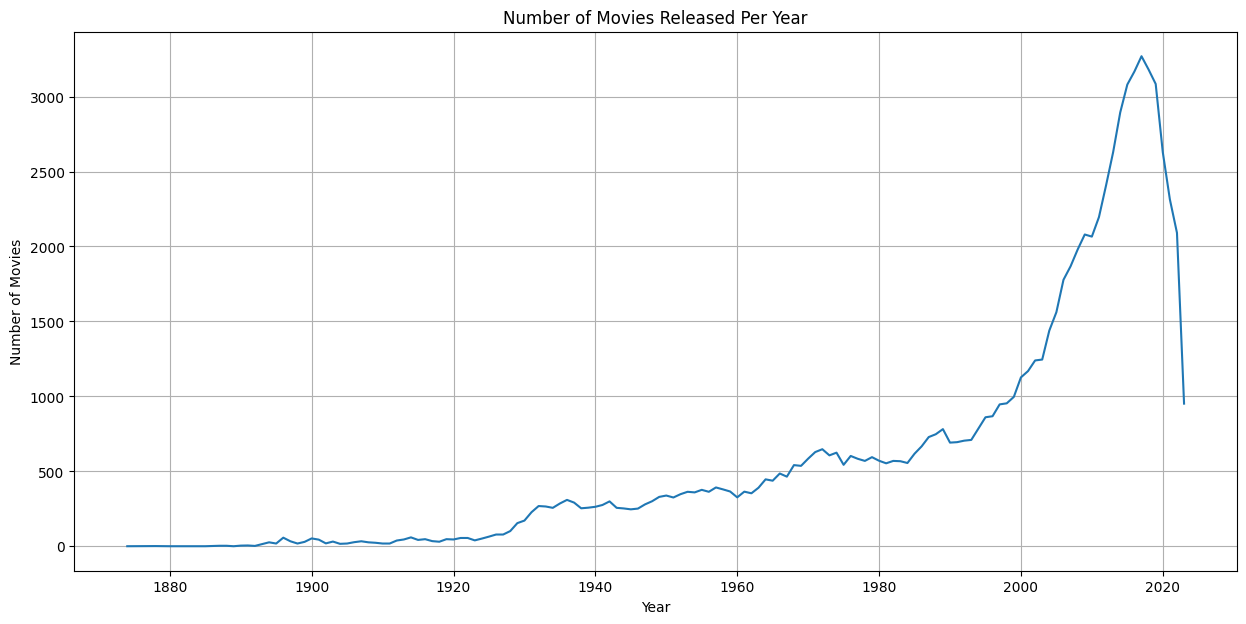

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate movie count per year
movies_per_year = movies['year'].value_counts().sort_index()

# Plotting the movie count by year
plt.figure(figsize=(15, 7))
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values)
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.show()

In [ ]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86970 entries, 0 to 87584
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  86970 non-null  int64 
 1   title    86970 non-null  object
 2   genres   86970 non-null  object
 3   year     86970 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


In [ ]:
movies_60s = movies[(movies['year'] >= 1960)]
num_movies_60s = len(movies_60s)
print(f"Number of movies from the 1960s: {num_movies_60s}")

Number of movies from the 1960s: 76367


In [ ]:
rating = pd.read_csv(os.path.join(path, files[2]))
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB


In [ ]:
movie_ratings = rating.groupby('movieId')['rating'].agg(['mean', 'count', 'std', 'min', 'max'])
movie_ratings.columns = ['average_rating', 'rating_count', 'rating_std', 'rating_min', 'rating_max']
print(movie_ratings.head())

         average_rating  rating_count  rating_std  rating_min  rating_max
movieId                                                                  
1              3.897438         68997    0.921450         0.5         5.0
2              3.275758         28904    0.955544         0.5         5.0
3              3.139447         13134    1.012273         0.5         5.0
4              2.845331          2806    1.105871         0.5         5.0
5              3.059602         13154    0.999079         0.5         5.0


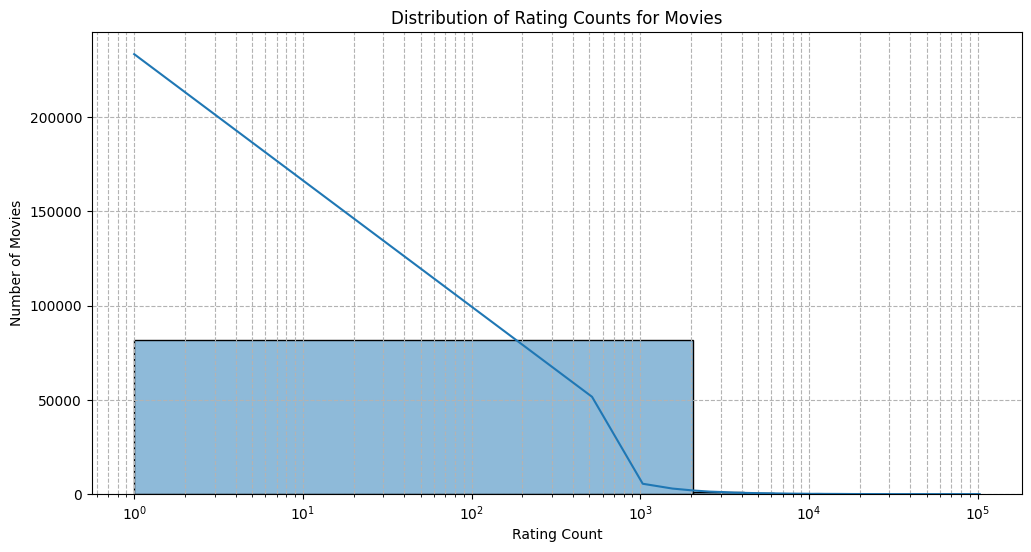

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(movie_ratings['rating_count'], bins=50, kde=True)
plt.title('Distribution of Rating Counts for Movies')
plt.xlabel('Rating Count')
plt.ylabel('Number of Movies')
plt.xscale('log') # Use log scale for better visualization due to skewed data
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

In [ ]:
movies_gt_50_ratings = movie_ratings[movie_ratings['rating_count'] > 50]
num_movies_gt_50 = len(movies_gt_50_ratings)
print(f"Number of movies with more than 50 ratings: {num_movies_gt_50}")

Number of movies with more than 50 ratings: 15883


In [ ]:
movies_gt_50_ratings.sort_values(by='rating_count', ascending=False).join(movies.set_index('movieId'), on='movieId').head(10)

,average_rating,rating_count,rating_std,rating_min,rating_max,title,genres,year
movieId,,,,,,,,
318,4.404614,102929,0.766148,0.5,5.0,"Shawshank Redemption, The",Crime|Drama,1994.0
356,4.052744,100296,0.935174,0.5,5.0,Forrest Gump,Comedy|Drama|Romance|War,1994.0
296,4.196969,98409,0.945559,0.5,5.0,Pulp Fiction,Comedy|Crime|Drama|Thriller,1994.0
2571,4.156437,93808,0.907191,0.5,5.0,"Matrix, The",Action|Sci-Fi|Thriller,1999.0
593,4.148367,90330,0.862928,0.5,5.0,"Silence of the Lambs, The",Crime|Horror|Thriller,1991.0
260,4.099824,85010,0.993047,0.5,5.0,Star Wars: Episode IV - A New Hope,Action|Adventure|Sci-Fi,1977.0
2959,4.228780,77332,0.860432,0.5,5.0,Fight Club,Action|Crime|Drama|Thriller,1999.0
480,3.698623,75233,0.937309,0.5,5.0,Jurassic Park,Action|Adventure|Sci-Fi|Thriller,1993.0
527,4.236990,73849,0.883319,0.5,5.0,Schindler's List,Drama|War,1993.0


In [ ]:
movies_gt_50_ratings['rating_count'].sum()

np.int64(31491139)

In [ ]:
movies_gt_50_ratings_with_tmdbId = movies_gt_50_ratings.join(links_cleaned.set_index('movieId'), on='movieId', how='inner')
print(movies_gt_50_ratings_with_tmdbId.head())
print(movies_gt_50_ratings_with_tmdbId.info())

         average_rating  rating_count  rating_std  rating_min  rating_max  \
movieId                                                                     
1              3.897438         68997    0.921450         0.5         5.0   
2              3.275758         28904    0.955544         0.5         5.0   
3              3.139447         13134    1.012273         0.5         5.0   
4              2.845331          2806    1.105871         0.5         5.0   
5              3.059602         13154    0.999079         0.5         5.0   

         imdbId  tmdbId  
movieId                  
1        114709     862  
2        113497    8844  
3        113228   15602  
4        114885   31357  
5        113041   11862  
<class 'pandas.core.frame.DataFrame'>
Index: 15870 entries, 1 to 290407
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   average_rating  15870 non-null  float64
 1   rating_count    15870 non-null  in

In [ ]:
# https://api.themoviedb.org/3/movie/:id?append_to_response=credits,keywords
key = input("Please enter your TMDB API key: ") # User will input their API key here


In [ ]:
import requests
import time
import pandas as pd
import os # For checking if file exists

# fetch api for each tmdb id

TMDB_BASE_URL = "https://api.themoviedb.org/3/movie/"
BATCH_SIZE = 100
REQUEST_DELAY_SECONDS = 0.3 # Small delay to avoid hitting rate limits

def fetch_movie_details(tmdb_id, api_key):
    """Fetches movie details from TMDB API using a bearer token."""
    url = f"{TMDB_BASE_URL}{tmdb_id}?append_to_response=credits,keywords"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "accept": "application/json"
    }
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
        return response.json()
    except requests.exceptions.HTTPError as http_err:
        print(f"HTTP error occurred for TMDB ID {tmdb_id}: {http_err}")
    except requests.exceptions.ConnectionError as conn_err:
        print(f"Connection error occurred for TMDB ID {tmdb_id}: {conn_err}")
    except requests.exceptions.Timeout as timeout_err:
        print(f"Timeout error occurred for TMDB ID {tmdb_id}: {timeout_err}")
    except requests.exceptions.RequestException as req_err:
        print(f"An unexpected error occurred for TMDB ID {tmdb_id}: {req_err}")
    return None

In [ ]:
# Get TMDB IDs from the DataFrame created in the previous step
# Assuming movies_gt_50_ratings_with_tmdbId is available in the environment
if 'movies_gt_50_ratings_with_tmdbId' not in locals() and 'movies_gt_50_ratings_with_tmdbId' not in globals():
    print("Error: 'movies_gt_50_ratings_with_tmdbId' DataFrame not found. Please ensure it's created before running this cell.")
    tmdb_ids_to_fetch = []
else:
    tmdb_ids_to_fetch = movies_gt_50_ratings_with_tmdbId['tmdbId'].tolist()
    print('To be download ', len(tmdb_ids_to_fetch), ' movies')


if not tmdb_ids_to_fetch:
    print("No TMDB IDs to fetch. Exiting.")
elif not key:
    print("API key is missing. Please provide a valid TMDB API key to proceed.")
else:
    # Override BATCH_SIZE for this cell as requested by the user
    BATCH_SIZE = 500
    records_processed = 0
    batch_counter = 0 # Initialize a counter for naming separate batch files

    print(f"Starting to fetch details for {len(tmdb_ids_to_fetch)} movies in batches of {BATCH_SIZE}...")

    for i in range(0, len(tmdb_ids_to_fetch), BATCH_SIZE):
        batch_ids = tmdb_ids_to_fetch[i : i + BATCH_SIZE]
        batch_results = []
        for tmdb_id in batch_ids:
            details = fetch_movie_details(tmdb_id, key)
            if details:
                batch_results.append(details)
            time.sleep(REQUEST_DELAY_SECONDS) # Wait a bit to respect API rate limits

        if batch_results:
            # Use json_normalize to handle potentially nested JSON structures
            df_batch = pd.json_normalize(batch_results)

            # Save each batch to a separate CSV file with headers
            batch_output_file = f"tmdb_movie_details_batch_{batch_counter}.csv"
            df_batch.to_csv(batch_output_file, mode='w', header=True, index=False)
            batch_counter += 1

            records_processed += len(batch_results)
            print(f"Processed {records_processed}/{len(tmdb_ids_to_fetch)} movies. Saved batch to {batch_output_file}")

    print("Finished fetching all movie details and saving to separate CSV files.")

To be download  15870  movies
Starting to fetch details for 15870 movies in batches of 500...
Processed 500/15870 movies. Saved batch to tmdb_movie_details_batch_0.csv
Processed 1000/15870 movies. Saved batch to tmdb_movie_details_batch_1.csv
Processed 1500/15870 movies. Saved batch to tmdb_movie_details_batch_2.csv
Processed 2000/15870 movies. Saved batch to tmdb_movie_details_batch_3.csv
Processed 2500/15870 movies. Saved batch to tmdb_movie_details_batch_4.csv
Processed 3000/15870 movies. Saved batch to tmdb_movie_details_batch_5.csv
Processed 3500/15870 movies. Saved batch to tmdb_movie_details_batch_6.csv
HTTP error occurred for TMDB ID 12773: 404 Client Error: Not Found for url: https://api.themoviedb.org/3/movie/12773?append_to_response=credits,keywords
Processed 3999/15870 movies. Saved batch to tmdb_movie_details_batch_7.csv
HTTP error occurred for TMDB ID 17882: 404 Client Error: Not Found for url: https://api.themoviedb.org/3/movie/17882?append_to_response=credits,keywords
P

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import shutil
# Moving files to drive

# Define the target directory in Google Drive
output_drive_dir = '/content/drive/MyDrive/COMP702Project/movie_datas'

# Create the directory if it doesn't exist
os.makedirs(output_drive_dir, exist_ok=True)

# Get a list of all files in the current directory
current_files = os.listdir('.')

# Filter for the generated batch CSV files
csv_files_to_move = [f for f in current_files if f.startswith('tmdb_movie_details_batch_') and f.endswith('.csv')]

if csv_files_to_move:
    print(f"Moving {len(csv_files_to_move)} CSV batch files to '{output_drive_dir}'...")
    for filename in csv_files_to_move:
        source_path = os.path.join('.', filename)
        destination_path = os.path.join(output_drive_dir, filename)
        try:
            shutil.move(source_path, destination_path)
            print(f"Moved '{filename}' to '{output_drive_dir}'")
        except Exception as e:
            print(f"Error moving '{filename}': {e}")
else:
    print("No 'tmdb_movie_details_batch_*.csv' files found to move.")

In [ ]:
import pandas as pd
import os

# Get a list of all files in the current directory
current_files = os.listdir('.')

# Filter for the generated batch CSV files
csv_files_to_merge = [f for f in current_files if f.startswith('tmdb_movie_details_batch_') and f.endswith('.csv')]

if csv_files_to_merge:
    print(f"Found {len(csv_files_to_merge)} CSV batch files to merge.")

    # List to hold dataframes
    df_list = []

    for filename in sorted(csv_files_to_merge):
        try:
            df = pd.read_csv(filename)
            df_list.append(df)
            print(f"Read '{filename}' successfully.")
        except Exception as e:
            print(f"Error reading '{filename}': {e}")

    if df_list:
        # Concatenate all dataframes
        merged_df = pd.concat(df_list, ignore_index=True)

        # Define the output file name
        output_csv_file = "tmdb_movie_data.csv"

        # Save the merged DataFrame to a new CSV file
        merged_df.to_csv(output_csv_file, index=False)
        print(f"All batch CSV files merged into '{output_csv_file}'.")
        print(f"Merged DataFrame has {len(merged_df)} rows and {len(merged_df.columns)} columns.")
    else:
        print("No dataframes were successfully read to merge.")
else:
    print("No 'tmdb_movie_details_batch_*.csv' files found in the current directory to merge.")

In [ ]:
# Save the coexisting tmdb_id ratings to filtered_movie_ratings_merged.csv
merged_rating = rating.join(links_cleaned.set_index('movieId'), on='movieId', how='inner').dropna()
# Select only tmdb_id with having id in merged_df
merged_rating = merged_rating[merged_rating['tmdbId'].isin(merged_df['id'])]
display(merged_rating.info())
display(merged_rating.head())
merged_rating.to_csv('filtered_movie_ratings_merged.csv', index=False)

In [ ]:
!cp filtered_movie_ratings_merged.csv /content/drive/MyDrive/COMP702Project/movie_datas/filtered_movie_ratings_merged.csv
!cp tmdb_movie_data.csv /content/drive/MyDrive/COMP702Project/movie_datas/tmdb_movie_data.csv